# Section 4: Sensitivity Analysis

Runs Rosenbaum bounds on the Section 1 PSM matched-pairs estimate at the calibrated
confounding severity, then produces the one bounded LLM diagnostic critique for the whole
project (see `src/llm_critique/critique.py` for why it's scoped this narrowly).

This notebook loads the confounded subsample (with propensity attached) that
`01_validation.ipynb` saved to `data/interim/confounded_strong_with_propensity.parquet`,
rather than re-running the whole calibration pipeline.

In [1]:
import os, sys

_cwd = os.getcwd()
_project_root = os.path.dirname(_cwd) if os.path.basename(_cwd) == "notebooks" else _cwd
if _project_root not in sys.path:
    sys.path.insert(0, _project_root)

import json
import os

import numpy as np
import pandas as pd

from src.utils.logging_config import configure_logging
from src.validation.estimators import get_matched_pairs
from src.validation.diagnostics import run_full_diagnostics
from src.sensitivity.rosenbaum import compute_rosenbaum_bounds, find_critical_gamma, plot_rosenbaum_bounds
from src.llm_critique.critique import run_diagnostic_critique

# Nothing in src/ reads .env directly -- every credential is read via
# os.environ.get() inside db.py / logging_config.py / critique.py. Without
# this, a .env file with real keys is silently ignored and everything falls
# back (SQLite, console logging, rule-based critique) even with keys "set."
from dotenv import load_dotenv

load_dotenv(os.path.join(_project_root, ".env"))

configure_logging()

os.makedirs("../data/processed", exist_ok=True)

FEATURE_COLS = [f"f{i}" for i in range(12)]
RANDOM_STATE = 42  # must match 01_validation.ipynb so matching is reproducible across notebooks
ALPHA = 0.05
GAMMA_MAX = 10.0

16:52:57.914 Structured logging configured via Logfire


## 1. Load the confounded subsample from Section 1

If this file doesn't exist, run `01_validation.ipynb` through the end first — Section 4
deliberately reuses Section 1's calibrated confounding rather than re-deriving it.

In [2]:
interim_path = "../data/interim/confounded_strong_with_propensity.parquet"

if not os.path.exists(interim_path):
    raise FileNotFoundError(
        f"{interim_path} not found. Run 01_validation.ipynb through Section 8 first; "
        "this notebook reuses its calibrated confounding severity rather than re-deriving it."
    )

strong_retained = pd.read_parquet(interim_path)
print(strong_retained.shape)
strong_retained.head()
# Output:
#   (148606, 17)

#             f0         f1        f2        f3         f4        f5         f6  \

#   0  25.744310  10.059654  8.214383  4.679882  10.280525  4.115453  -3.282109   

#   1  12.616365  10.059654  9.007057  4.679882  10.280525  4.115453   0.294443   

#   2  14.070637  10.059654  8.214383 -2.345693  10.280525  4.115453 -16.479126   

#   3  22.709732  10.059654  8.399186  4.679882  10.280525  4.115453  -5.116672   

#   4  22.288802  10.059654  8.876330  4.679882  10.280525  4.115453 -10.764422   

#   

#            f7        f8         f9       f10       f11  treatment  conversion  \

#   0  4.833815  3.971858  13.190056  5.300375 -0.168679          1           0   

#   1  4.833815  3.890052  13.190056  5.300375 -0.168679          1           0   

#   2  4.833815  3.971858  13.190056  5.300375 -0.168679          1           0   

#   3  4.833815  3.910792  24.452088  5.300375 -0.168679          1           0   

#   4  4.833815  3.853396  13.190056  5.300375 -0.168679          1           0   

#   

#      visit  exposure  _propensity  

#   0      0         0     0.835354  

#   1      0         0     0.829320  

#   2      0         0     0.861693  

#   3      0         0     0.868249  

#   4      0         0     0.833603  

(148606, 17)


,f0,f1,f2,f3,f4,f5,f6,f7,f8,f9,f10,f11,treatment,conversion,visit,exposure,_propensity
0,25.744310,10.059654,8.214383,4.679882,10.280525,4.115453,-3.282109,4.833815,3.971858,13.190056,5.300375,-0.168679,1,0,0,0,0.835354
1,12.616365,10.059654,9.007057,4.679882,10.280525,4.115453,0.294443,4.833815,3.890052,13.190056,5.300375,-0.168679,1,0,0,0,0.829320
2,14.070637,10.059654,8.214383,-2.345693,10.280525,4.115453,-16.479126,4.833815,3.971858,13.190056,5.300375,-0.168679,1,0,0,0,0.861693
3,22.709732,10.059654,8.399186,4.679882,10.280525,4.115453,-5.116672,4.833815,3.910792,24.452088,5.300375,-0.168679,1,0,0,0,0.868249
4,22.288802,10.059654,8.876330,4.679882,10.280525,4.115453,-10.764422,4.833815,3.853396,13.190056,5.300375,-0.168679,1,0,0,0,0.833603


## 2. Rebuild diagnostics and matched pairs

`run_full_diagnostics` builds the matched sample internally via `get_matched_pairs`, so this
recomputes balance/overlap diagnostics on the actual matched pairs (not on the
common-support-trimmed sample, which understates matching's effect on balance).

In [3]:
diagnostics = run_full_diagnostics(
    strong_retained, FEATURE_COLS, "treatment", "_propensity", random_state=RANDOM_STATE
)

print("Imbalanced covariates after matching:", diagnostics["n_imbalanced_covariates"])
print("Percent within common support:", diagnostics["pct_within_overlap"])
print(
    f"Matched {diagnostics['n_pairs']:,} of {diagnostics['n_treated_total']:,} treated units "
    f"({100 * diagnostics['match_rate']:.1f}%) against {diagnostics['n_control_unique']:,} distinct controls"
)
diagnostics["balance_table"]

matched = diagnostics["matched_df"]
print("Matched sample size:", len(matched))
# Output:
#   Matched sample size: 251964

16:52:59.354 PSM (1:1, no replacement): 103370 of 125988 treated units unmatched (control pool exhausted or no control within caliper)


Logfire project URL: https://logfire-us.pydantic.dev/baneduskduke/starter-project

16:52:59.498 Common support trim (overlap, [0.8219, 0.9506]): dropped 33 of 148606 rows (0.0%)
16:52:59.509 Common support trim (fixed, [0.1000, 0.9000]): dropped 10655 of 148606 rows (7.2%)
16:52:59.524 Overlap diagnostics: 100.0% of rows within overlap region [0.8219, 0.9506]
16:52:59.524 Matching: 22618 of 125988 treated units matched (18.0%) against 22618 distinct controls
Imbalanced covariates after matching: 0
Percent within common support: 99.97779362879022
Matched 22,618 of 125,988 treated units (18.0%) against 22,618 distinct controls
Matched sample size: 45236


## 3. Rosenbaum bounds

Rosenbaum bounds are computed on the matched-pairs output specifically, not on IPW/AIPW
estimates — there is no equivalent matched-pair structure for a weighting-based estimator, so
this method applies to PSM output only (see `src/sensitivity/rosenbaum.py` docstring).

16:52:59.563 Critical gamma = 1.15: unmeasured confounding of this odds-ratio strength would be needed to overturn the conclusion at alpha=0.050
{'critical_gamma': 1.1500000000000001, 'gamma_max_checked': 10.0, 'alpha': 0.05, 'n_pairs': 22618, 'n_discordant': 1390, 'n_plus': 766, 'n_minus': 624}


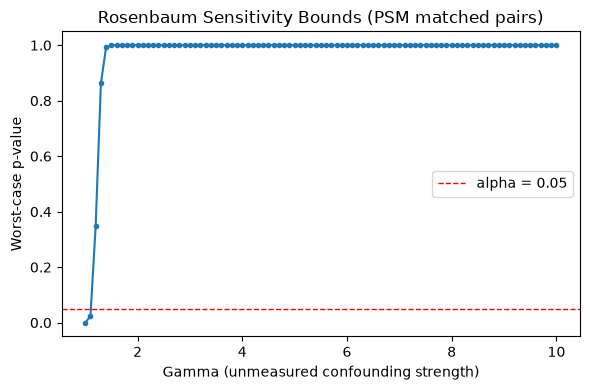

In [4]:
bounds_df = compute_rosenbaum_bounds(
    matched,
    outcome_col="visit",
    treatment_col="treatment",
    gamma_range=np.arange(1.0, GAMMA_MAX + 0.05, 0.1),
)
bounds_df.to_csv("../data/processed/rosenbaum_bounds.csv", index=False)

critical_gamma_result = find_critical_gamma(
    matched,
    outcome_col="visit",
    treatment_col="treatment",
    alpha=ALPHA,
    gamma_max=GAMMA_MAX,
)
print(critical_gamma_result)
# Output:
#   14:39:29.801 Critical gamma = 1.35: unmeasured confounding of this odds-ratio strength would be needed to overturn the conclusion at alpha=0.050

#   {'critical_gamma': 1.3500000000000003, 'gamma_max_checked': 10.0, 'alpha': 0.05, 'n_pairs': 125982, 'n_discordant': 11194, 'n_plus': 6499, 'n_minus': 4695}

fig = plot_rosenbaum_bounds(bounds_df, alpha=ALPHA, title="Rosenbaum Sensitivity Bounds (PSM matched pairs)")
fig.savefig("../data/processed/rosenbaum_bounds.png", dpi=100)
# Output:
#   <Figure size 600x400 with 1 Axes>

If `critical_gamma` is a small number (close to 1), the matched-pairs conclusion is fragile:
even modest unmeasured confounding could overturn it. A `critical_gamma` of None (never crossed
alpha up to `gamma_max`) means the conclusion is robust to substantial hidden bias at this
confounding severity.

## 4. The one LLM step in this project

Reads the balance table, overlap diagnostics, and the Rosenbaum critical-gamma result, and
produces a short plain-language flag of likely assumption violations. This is a bounded
diagnostic utility, not a narrative report generator — nothing else in the project calls an
LLM.

In [5]:
critique_result = run_diagnostic_critique(
    diagnostics,
    {"critical_gamma_result": critical_gamma_result},
)

print("Source:", critique_result["source"])
print()
print(critique_result["critique_text"])

with open("../data/processed/critique.json", "w") as f:
    json.dump(
        {"source": critique_result["source"], "critique_text": critique_result["critique_text"]},
        f,
    )
# Output:
#   [1mLogfire[0m project URL: [4;36mhttps://logfire-us.pydantic.dev/abhinewnpc/ticket-triage-mlops[0m

#   14:39:32.413 HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"

#   14:39:32.427 Diagnostic critique generated via groq

#   Source: groq

#   

#   - The measured variables look well‑matched; after adjustment every covariate’s difference is well below the 0.1 threshold, so observed confounding appears under control.  

#   - All treated and control units fall inside the overlapping region of propensity scores (100 % within 0.822 – 0.951), so the groups are comparable where the analysis is performed.  

#   - The Rosenbaum test shows the result could be flipped if an unmeasured factor made a unit about **35 % more likely** to receive the treatment (Γ ≈ 1.35). In plain terms, a modest hidden bias could overturn the finding.  

#   - Because the sensitivity bound is relatively low, the causal claim should be treated as **somewhat vulnerable** to unobserv

16:53:02.343 HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
16:53:02.358 Diagnostic critique generated via groq
Source: groq

- The measured covariates look well‑balanced after matching (all differences are tiny), so the groups appear comparable on the variables you observed.  
- Every matched unit falls inside the region where treated and control units overlap, so there’s no obvious problem with “missing” parts of the data.  
- The Rosenbaum result shows the finding could be flipped by an unmeasured factor that changes the odds of treatment by only about 15 % (Γ ≥ 1.15). In plain terms, the conclusion is quite sensitive to hidden bias—any modest, unobserved difference between groups could overturn the result.


If `source` is `rule_based_fallback`, no Groq/NIM API key was configured in this environment
(set `GROQ_API_KEY` or `NVIDIA_NIM_API_KEY`). The fallback mirrors the kind of flags an actual
LLM call would produce, so the pipeline stays runnable without a key, but it should not be
mistaken for the real LLM critique — the dashboard labels this distinction explicitly.

## Summary

- Reused Section 1's calibrated confounding severity and matched-pairs sample rather than
  re-deriving it.
- Computed Rosenbaum bounds specifically on the PSM matched pairs, found the critical Gamma.
- Ran the project's single bounded LLM diagnostic critique step on the Section 1/4 diagnostics.

This completes Sections 1 through 5 (run in order: `01_validation.ipynb`, `02_heterogeneity.ipynb`,
then this notebook). Remaining: the Streamlit dashboard (`streamlit run dashboard/app.py`) ties
all of this together, and the README documents the full narrative and the deliberate exclusions.